In [1]:
import os
import sys
import json
import re

import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize

In [2]:
# Parent directory PATH
sys.path.append("..")

from utils.json import load_json, save_json
from data.dataset import json_keys, json_structure, extract_documents, extract_annotations, remove_punctuation, remove_punctuation_dataframe, group_labels

In [3]:
# Load the training data
file = "training.json"
path = "../data/raw/"
data = load_json(os.path.join(path, file))

Successfully loaded 254 documents from ../data/raw/training.json


In [4]:
print(f"Type of loaded data: {type(data)}")
print(f"Number of documents: {len(data)}")

Type of loaded data: <class 'list'>
Number of documents: 254


In [5]:
# Explore your JSON data
json_structure(data, max_depth=10)

root (list with 254 items)
    root[0] (dict with 3 keys)
        root[0].data (dict with 6 keys)
            root[0].data.cmbd (str): null
            root[0].data.id (str): 19026587
            root[0].data.docid (str): null
            root[0].data.page (str): null
            root[0].data.paragraph (str): null
            root[0].data.text (str):  nº historia clinica: ** *** *...
        root[0].annotations (list with 0 items)
        root[0].predictions (list with 1 items)
            root[0].predictions[0] (dict with 1 keys)
                root[0].predictions[0].result (list with 20 items)
                    root[0].predictions[0].result[0] (dict with 5 keys)
                        root[0].predictions[0].result[0].value (dict with 3 keys)
                            root[0].predictions[0].result[0].value.start (int): 449
                            root[0].predictions[0].result[0].value.end (int): 452
                            root[0].predictions[0].result[0].value.labels (l

In [6]:
# Get the JSON keys structure
structure = json_keys(data)

display(structure)

{'main_keys': ['annotations', 'data', 'predictions'],
 'data_keys': ['cmbd', 'docid', 'id', 'page', 'paragraph', 'text'],
 'prediction_keys': ['result'],
 'result_keys': ['from_name', 'id', 'to_name', 'type', 'value'],
 'value_keys': ['end', 'labels', 'start'],
 'label_types': ['NEG', 'NSCO', 'UNC', 'USCO']}

In [7]:
# Insights using the first document
record_first = data[0]

if isinstance(data, list):
    print(f"Type document: {type(data[0])}")
    print(f"Keys document: {structure['main_keys']}")
    print()

    for main_keys in record_first:
        print(f"Key: {main_keys}")
        print(f"Type: {type(record_first[main_keys])}")
        print(f"Length: {len(record_first[main_keys])}")
        print(f"Value: {record_first[main_keys]}")
        print()

        if "data" in main_keys:
            for k in record_first["data"].keys():
                print(f"\tKey: {k}")
                print(f"\tType: {type(record_first['data'][k])}")
                print(f"\tLength: {len(record_first['data'][k])}")
                print(f"\tValue: {record_first['data'][k]}")
                print()

Type document: <class 'dict'>
Keys document: ['annotations', 'data', 'predictions']

Key: data
Type: <class 'dict'>
Length: 6
Value: {'cmbd': 'null', 'id': '19026587', 'docid': 'null', 'page': 'null', 'paragraph': 'null', 'text': " nº historia clinica: ** *** *** nºepisodi: ******** sexe: home data de naixement: 16.05.1936 edat: 82 anys procedencia cex mateix hosp servei urologia data d'ingres 24.07.2018 data d'alta 25.07.2018 08:54:04 ates per ***************, *****; ****************, ****** informe d'alta d'hospitalitzacio motiu d'ingres paciente que ingresa de forma programada para realizacion de uretrotomia interna . antecedents alergia a penicilina y cloramfenicol . no habitos toxicos. antecedentes medicos: bloqueo auriculoventricular de primer grado hipertension arterial. diverticulosis extensa insuficiencia renal cronica colelitiasis antecedentes quirurgicos: exeresis de lesiones cutaneas con anestesia local protesis total de cadera cordectomia herniorrafia inguinal proces actua

In [8]:
extract_documents(data)

In [9]:
# Extract all annotations
df_predictions = extract_annotations(data)

print(f"Extracted {len(df_predictions)} annotations")
display(df_predictions)

Extracted 9319 annotations


,doc_index,doc_id,result_id,start,end,label,text
0,0,19026587,ent0,449,452,NEG,no
1,0,19026587,ent1,452,468,NSCO,habitos toxicos.
2,0,19026587,ent2,844,856,NSCO,cistoscopia
3,0,19026587,ent3,863,872,NEG,negativa
4,0,19026587,ent4,872,895,NSCO,para lesiones malignas
...,...,...,...,...,...,...,...
9314,253,20339886,ent23,3765,3788,NSCO,el hemocultivo cursado
9315,253,20339886,ent44,3796,3804,NEG,negativo
9316,253,20339886,ent24,3856,3864,NEG,afebril
9317,253,20339886,ent25,4147,4159,UNC,sospecha de


In [10]:
annotation_counts = df_predictions.groupby("doc_id").size().sort_values(ascending=False)

print()
print("Top 5 documents by annotation count:")
for doc_id, count in annotation_counts.head(10).items():
    print(f"Document {doc_id} has {count} annotations")


Top 5 documents by annotation count:
Document 19395557 has 216 annotations
Document 20321835 has 142 annotations
Document 19644561 has 135 annotations
Document 18876889 has 124 annotations
Document 19579840 has 115 annotations
Document 18703319 has 111 annotations
Document 19072809 has 110 annotations
Document 18888512 has 109 annotations
Document 18653570 has 100 annotations
Document 19374244 has 98 annotations


In [11]:
# Duplicated documents
true_counts = {}

# Count each unique document ID only once
for doc in data:
    doc_id = doc["data"]["id"]
    if doc_id in true_counts:
        true_counts[doc_id] += 1
    else:
        true_counts[doc_id] = 1

# Find actually duplicated IDs
actual_duplicates = {id: count for id, count in true_counts.items() if count > 1}

print(f"Number of documents: {len(data)}")
print(f"Number of unique document IDs: {len(true_counts)}")
print(f"Number of truly duplicated IDs: {len(actual_duplicates)}")
print()

if actual_duplicates:
    print("True duplicate document IDs:")
    for doc_id, count in actual_duplicates.items():
        print(f"ID {doc_id} appears {count} times")
else:
    print("No duplicate document IDs found")

Number of documents: 254
Number of unique document IDs: 247
Number of truly duplicated IDs: 2

True duplicate document IDs:
ID 18956072 appears 5 times
ID 18468396 appears 4 times


Label Distribution:
NEG: 4307 (46.22%)
NSCO: 4103 (44.03%)
UNC: 458 (4.91%)
USCO: 451 (4.84%)


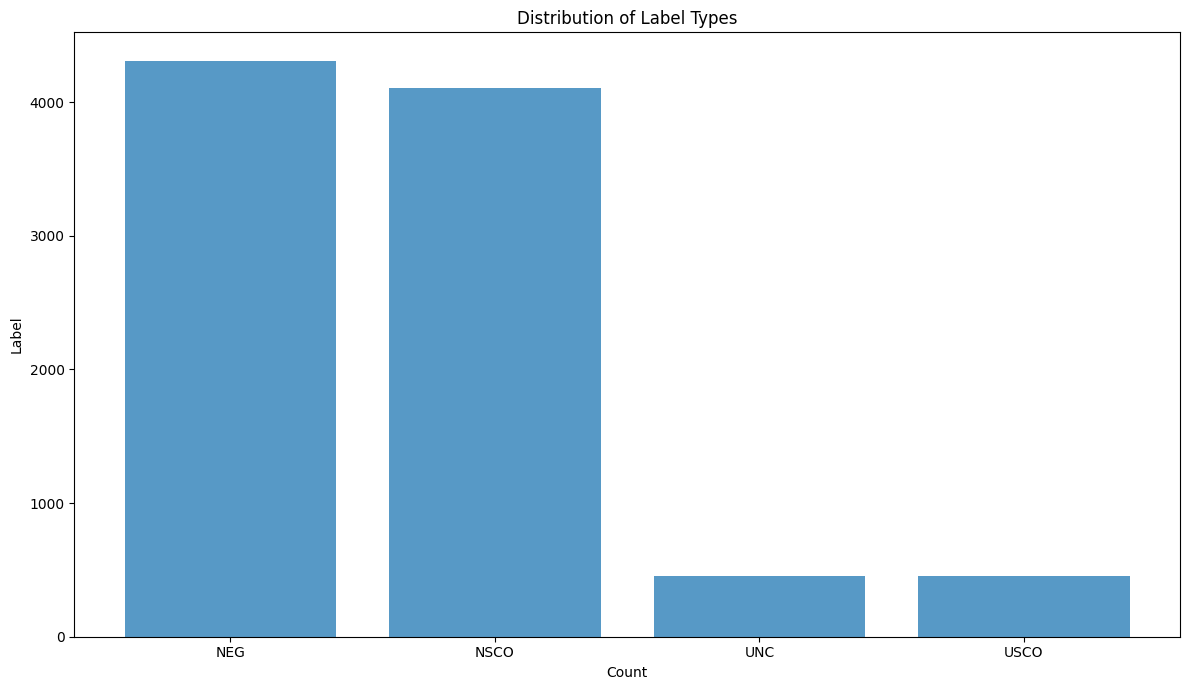

In [12]:
# Count the occurrences of each label
label_counts = df_predictions["label"].value_counts()

print("Label Distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count} ({count/len(df_predictions)*100:.2f}%)")

labels = label_counts.index
counts = label_counts.values

# Plot the distribution using Matplotlib directly
plt.figure(figsize=(12, 7))
plt.bar(labels, counts, alpha=0.75)
plt.title("Distribution of Label Types")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

In [13]:
# we remove the punctuation from the scopes and add a new column to the dataframe with it
df_predictions = remove_punctuation_dataframe(df_predictions)

hola
no 
negativa 
sin 
sin 
sin claras 
falsa 
no 
sin 
sin 
afebril,
no 
no 
nega 
no 
sin 
ausencia de 
niega 
afebril,
no 
sin 
sin 
afebril,
no 
sin 
no 
no 
sin 
no 
no 
aparente 
no 
sin 
sugestivos con 
no 
no 
tampoco 
sin 
podria 
no 
sin 
sin 
no 
podria 
sin 
no 
sin 
inespecificos
no 
sin
dudosa 
no 
posible 
dudosa 
probable 
afebril
sin 
afebril
sin 
no 
no 
sin 
afebril.
desaparicion de 
sin 
sin 
no 
sin 
sin 
no 
no 
no 
no
no 
no 
negativas
negativo 
negativo 
negativo
compatible con 
compatible con 
sin 
no 
no 
no 
no 
no 
no 
negativos
negativo 
negativo 
negativos
no 
sin 
no 
negativo
no 
no 
no 
no 
no 
no 
no 
no 
sin 
sin 
niega 
no 
no 
negativos
negativa
compatibles con 
sin 
afebril
sin 
sin 
sin 
sospecha de 
niega 
niega 
sin 
sugestiva de 
no 
no 
sin 
sin 
afebril
no 
ex
sin 
sin 
no 
no 
sin 
sin 
sin 
no 
sin 
niega 
no 
niega 
sin 
sin 
sin 
sin 
sin 
no 
sin 
sin 
sin 
sin 
no 
sin 
niega 
no 
no 
no 
sin 
probables 
negativos
no 
no 
sin 
no 
comp

In [14]:
# Common Negation Cues
neg_cues = df_predictions[df_predictions["label"] == "NEG"]["clean_text"].value_counts()
print("TOP Negation Cues: \n")
for cue, count in neg_cues.items():
    print(f"{cue}: {count}")

TOP Negation Cues: 

no: 1909
sin: 1424
negativo: 203
afebril: 189
niega: 136
negativos: 92
ausencia de: 64
negativa: 54
sense: 40
neg: 35
negativas: 24
asintomatica: 11
asintomatico: 10
ex: 9
descarta: 8
inespecifico: 8
falta de: 7
impide: 5
tampoco: 4
se retira: 4
nega: 4
exfumador: 4
cede: 4
ex-: 4
inespecificos: 3
negatiu: 3
retiro: 3
descartada: 3
desaparicion de: 3
negatividad de: 3
retirar: 3
inestabilidad: 3
desorientacion: 2
niegan: 2
excepto: 2
ausencia: 2
imposibilidad de: 2
incapacidad para: 2
se desestimo: 1
ex fumador: 1
suspendido: 1
ceden: 1
irregulares: 1
indetectable: 1
negaitvo: 1
negatividad: 1
imposibilidad: 1
se suspende: 1
desorientado: 1
ninguno: 1
rechaza: 1
en ninguna: 1
desaparecen: 1
arritmicos: 1
desaparicion del: 1
negatividad del: 1
atipicos: 1


In [15]:
# Common Uncertainty Cues
unc_cues = df_predictions[df_predictions["label"] == "UNC"]["clean_text"].value_counts()
print("TOP Uncertainty Cues: \n")
for cue, count in unc_cues.items():
    print(f"{cue}: {count}")

TOP Uncertainty Cues: 

compatible con: 58
probable: 54
sospecha de: 31
se orienta: 23
probablemente: 23
posible: 20
sugestiva de: 18
aparentemente: 17
compatibles con: 17
dudosa: 13
valorar: 12
sugestivo de: 10
podria: 10
sugestivos de: 9
parece: 9
sugestivas de: 7
aparente: 7
posiblemente: 5
vs: 5
dudoso: 5
sospechosa de: 4
podrian: 4
probables: 4
dudosamente: 4
sugiere: 4
no: 4
posibilidad de: 3
impresiona: 3
sospechosas de: 3
desconoce: 3
sin: 3
dudosos: 3
sugiriendo: 3
sospecha: 2
parecen: 2
sin poder descartar: 2
sugieren: 2
puede: 2
impresiona de: 2
no parece: 2
sin aparentes: 2
sin aparente: 2
orientan: 2
compatible amb: 2
aparentes: 2
sugieran: 2
ssospechosas de: 2
falsa: 1
sin claras: 1
sugestivos con: 1
desconocido: 1
pudieran: 1
orienta como: 1
se orientan: 1
plantea: 1
sin clara: 1
indiquen: 1
atribuida: 1
orienta: 1
se desconoce: 1
poco porque: 1
sugestiva como: 1
sospechosos de: 1
sospitosa de: 1
al parecer: 1
no es posible descartar: 1
interpreta: 1
sospechan de: 1
desc

Average NSCO length: 24.36 characters
Average USCO length: 30.08 characters


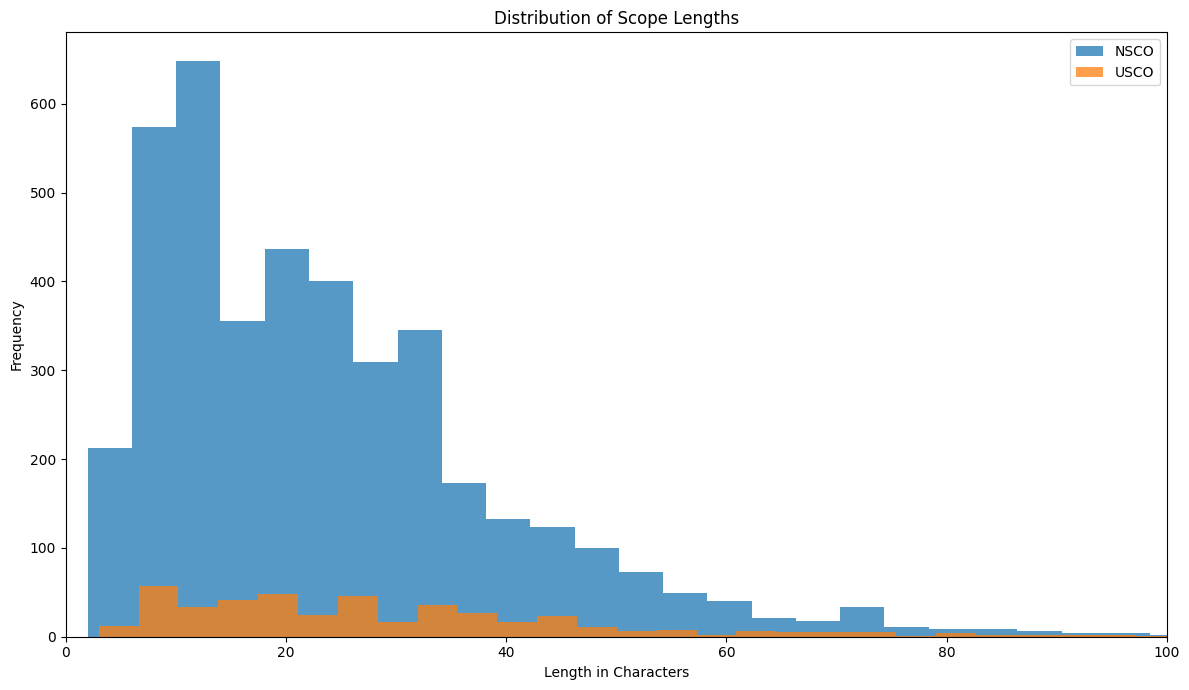

In [16]:
# Calculate scope lengths
df_predictions["text_length"] = df_predictions["text"].apply(len)

scope_labels = ["NSCO", "USCO"]

# Average Scope's 
for label in scope_labels:
    avg_len = df_predictions[df_predictions["label"] == label]["text_length"].mean()
    print(f"Average {label} length: {avg_len:.2f} characters")

# Plot scope length distributions by label type
plt.figure(figsize=(12, 7))
for label in scope_labels:
    scope_lengths = df_predictions[df_predictions["label"] == label]["text_length"]
    plt.hist(scope_lengths, bins=50, alpha=0.75, label=label)

plt.title("Distribution of Scope Lengths")
plt.xlabel("Length in Characters")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(0, 100) # Limit to most common
plt.tight_layout()
plt.show()

### Create groups of Cues-Scope
We agrupate them based on distances in the text. A scope is assigned to the closest cue.

In [17]:
df_predictions = group_labels(df_predictions)

In [18]:
df_predictions.head()

,doc_index,doc_id,result_id,start,end,label,text,clean_text,text_length,scope
0,0,19026587,ent0,449,452,NEG,no,no,3,None
1,0,19026587,ent1,452,468,NSCO,habitos toxicos.,NaN,16,0
2,0,19026587,ent2,844,856,NSCO,cistoscopia,NaN,12,3
3,0,19026587,ent3,863,872,NEG,negativa,negativa,9,None
4,0,19026587,ent4,872,895,NSCO,para lesiones malignas,NaN,23,3


In [19]:
# Get negation and uncertainty cues
negation_esp = pd.read_csv("../data/lexicons/negation/negation_esp.csv")
negation_cat = pd.read_csv("../data/lexicons/negation/negation_cat.csv")
uncertainty_esp = pd.read_csv("../data/lexicons/uncertainty/uncertainty_esp.csv")
uncertainty_cat = pd.read_csv("../data/lexicons/uncertainty/uncertainty_cat.csv")

# Combine both
negation_cues = pd.concat([negation_esp, negation_cat])
uncertainty_cues = pd.concat([uncertainty_esp, uncertainty_cat])

# Remove duplicated cues
negation_cues = negation_cues.drop_duplicates()
uncertainty_cues = uncertainty_cues.drop_duplicates()

In [38]:
def preprocess_text(text):
    """Preprocess the text for rule-based analysis"""

    # it always starts in "motiu d'ingres" so just take it from there

    # Usar expresiones regulares para capturar lo que hay entre "hola" y "adiós"
    result = re.search(r"motiu d'ingres(.*)destinacio a l'alta", text)

    if result:
        captured_text = result.group(1).strip()
        # print(result.group(1).strip())  # Resultado sin espacios extra
    else:
        raise Exception ("No se encontró texto entre 'hola' y 'hoy'")

    
    # Handle special characters and standardize text
    final_text = captured_text.lower()

    # Add other preprocessing steps as needed

    return final_text

def tokenize_text(text):
    """Split text into tokens (words, punctuation)"""
    # You can use spaCy, NLTK, or custom tokenization
    import re
    tokens = re.findall(r'\w+|[^\w\s]', text)
    return tokens

# def find_cues(tokens, cue_lexicon):
#     """Find all instances of cues in the text"""
#     cues = []
#     cue_terms = cue_lexicon['term']
#     for i, token in enumerate(tokens):
#         if token in cue_terms.values:
#             cues.append({"index": i, "token": token})
#     return cues

def find_cues(tokens, cue_lexicon, max_ngram=2):
    """Find cues using n-gram approach, avoiding duplicates and overlaps."""
    cues = []
    cue_terms = cue_lexicon['term']
    text = ' '.join(tokens)
    sorted_cues = sorted(cue_terms, key=len, reverse=True)

    matched_indices = set()  # Keep track of token indices that have been matched

    for cue in sorted_cues:
        cue_tokens = cue.split()
        cue_length = len(cue_tokens)

        if cue_length > max_ngram:
            continue

        for i in range(len(tokens) - cue_length + 1):
            # Skip if the current token index has already been matched
            if i in matched_indices:
                continue

            # Check if the current cue matches the tokens at this position
            if tokens[i:i+cue_length] == cue_tokens:
                # Add the cue to the list of found cues
                cues.append({
                    "index": i,
                    "token": cue,
                    "length": cue_length
                })

                # Mark all token indices covered by this cue as matched
                for j in range(i, i+cue_length):
                    matched_indices.add(j)

                # Break to avoid detecting the same cue multiple times at the same position
                break
    return cues


def determine_scope(tokens, cue_index, window_size=5, direction="forward"):
    """Determine the scope of a cue based on linguistic rules"""
    # Start with basic window
    if direction == "forward":
        start = cue_index + 1
        end = min(cue_index + window_size + 1, len(tokens))
    else:
        start = max(0, cue_index - window_size)
        end = cue_index
    
    # Refine scope based on punctuation
    for i in range(start, end):
        if tokens[i] in ['.', ',', ';', ':', '!', '?']:
            end = i
            break
    
    return tokens[start:end]

def apply_negex(text, negation_cues, window_size=5):
    """Apply NegEx algorithm to find negation cues and their scopes"""
    processed_text = preprocess_text(text)
    tokens = tokenize_text(processed_text)
    results = []
    
    # Find all negation cues
    cues = find_cues(tokens, negation_cues)
    
    # For each cue, determine its scope
    for cue in cues:
        # Default to looking forward for scope
        scope_tokens = determine_scope(tokens, cue["index"], window_size)
        
        # Store the result
        results.append({
            "cue": cue["token"],
            "cue_position": cue["index"],
            "scope": " ".join(scope_tokens),
            "scope_start": cue["index"] + 1,
            "scope_end": cue["index"] + len(scope_tokens) + 1
        })
    
    return results

def apply_uncertainty(text, uncertainty_cues, window_size=5):
    """Apply NegEx algorithm to find negation cues and their scopes"""
    processed_text = preprocess_text(text)
    tokens = tokenize_text(processed_text)
    
    results = []
    
    # Find all negation cues
    cues = find_cues(tokens, uncertainty_cues)
    
    # For each cue, determine its scope
    for cue in cues:
        # Default to looking forward for scope
        scope_tokens = determine_scope(tokens, cue["index"], window_size)
        
        # Store the result
        results.append({
            "cue": cue["token"],
            "cue_position": cue["index"],
            "scope": " ".join(scope_tokens),
            "scope_start": cue["index"] + 1,
            "scope_end": cue["index"] + len(scope_tokens) + 1
        })
    
    return results

def apply_linguistic_rules(tokens, cue_index):
    """Apply linguistic rules to refine scope detection"""
    # Example rule: Scope extends until the next punctuation
    scope_end = cue_index + 1
    while scope_end < len(tokens) and tokens[scope_end] not in ['.', ',', ';', ':', '!', '?']:
        scope_end += 1
    
    return scope_end


def evaluate_system(predictions, gold_standard):
    """Evaluate the system against gold standard annotations"""
    # Calculate precision, recall, F1 for cue detection
    # cue_precision = 
    # Calculate precision, recall, F1 for scope detection
    # scope_precision = 
    # Return evaluation metrics
    return {
        # "cue_precision": cue_precision,
        # "cue_recall": cue_recall,
        # "cue_f1": cue_f1,
        # "scope_precision": scope_precision,
        # "scope_recall": scope_recall,
        # "scope_f1": scope_f1
    }
    
def process_dataset(data):
    """Process the entire dataset with the rule-based system"""
    results = []
    
    for doc in data:
        text = doc["data"]["text"]
        
        # Apply NegEx for negation
        negation_results = apply_negex(text, negation_cues)
        
        # Apply similar algorithm for uncertainty
        uncertainty_results = apply_uncertainty(text, uncertainty_cues)
        
        # Combine results
        doc_results = {
            "doc_id": doc["data"]["id"],
            "negation_results": negation_results,
            "uncertainty_results": uncertainty_results
        }
        
        results.append(doc_results)
    
    return results

In [39]:
raw_results = process_dataset(data)
raw_results[0]

{'doc_id': '19026587',
 'negation_results': [{'cue': 'imposibilidad',
   'cue_position': 557,
   'scope': 'miccional por obstruccion de sonda',
   'scope_start': 558,
   'scope_end': 563},
  {'cue': 'retirada',
   'cue_position': 373,
   'scope': '',
   'scope_start': 374,
   'scope_end': 374},
  {'cue': 'retirar',
   'cue_position': 510,
   'scope': 'la sonda vesical',
   'scope_start': 511,
   'scope_end': 514},
  {'cue': 'sense',
   'cue_position': 407,
   'scope': 'simptomes en les vies urinaries',
   'scope_start': 408,
   'scope_end': 413},
  {'cue': 'sin',
   'cue_position': 95,
   'scope': 'exito',
   'scope_start': 96,
   'scope_end': 97},
  {'cue': 'no',
   'cue_position': 19,
   'scope': 'habitos toxicos',
   'scope_start': 20,
   'scope_end': 22},
  {'cue': 'a',
   'cue_position': 14,
   'scope': 'penicilina y cloramfenicol',
   'scope_start': 15,
   'scope_end': 18}],
 'uncertainty_results': []}

In [40]:
# Process each document (this can probably more compressed)
def format_raw_results(results):
    # Create a list to hold all rows for the dataframe
    rows = []
    result_id_counter = 0


    for doc_index, doc in enumerate(results):
        doc_id = doc['doc_id']
        
        # Process negation results
        for neg_result in doc['negation_results']:
            cue = neg_result['cue']
            cue_position = neg_result['cue_position']
            scope = neg_result['scope']
            scope_start = neg_result['scope_start']
            scope_end = neg_result['scope_end']
            
            
            # Clean text
            #TODO don't know what is this meant for, I just focus on same output
            
            # If there is scope
            if scope:
                rows.append({
                'doc_index': doc_index,
                'doc_id': doc_id,
                'result_id': "ent" + str(result_id_counter),
                'start': scope_start,
                'end': scope_end,
                'label': 'NSCO',
                'text': scope,
                'clean_text': cue,
                'text_length': len(scope),
                'scope': scope
            })
            
            # There is always a cue            
            rows.append({
                'doc_index': doc_index,
                'doc_id': doc_id,
                'result_id': "ent" + str(result_id_counter),
                'start': cue_position,
                'end': cue_position + len(cue),
                'label': 'NEG',
                'text': cue,
                'clean_text': None,
                'text_length': len(cue),
                'scope': scope
            })
                
            result_id_counter += 1
        
        # Process uncertainty results (if any)
        for unc_result in doc['uncertainty_results']:
            cue = unc_result['cue']
            cue_position = unc_result['cue_position']
            scope = unc_result['scope']
            scope_start = unc_result['scope_start']
            scope_end = unc_result['scope_end']
            
            
            # Clean text
            #TODO don't know what is this meant for, I just focus on same output
            
            # If there is scope
            if scope:
                rows.append({
                'doc_index': doc_index,
                'doc_id': doc_id,
                'result_id': "ent" + str(result_id_counter),
                'start': scope_start,
                'end': scope_end,
                'label': 'USCO',
                'text': scope,
                'clean_text': cue,
                'text_length': len(scope),
                'scope': scope
            })
            
            # There is always a cue            
            rows.append({
                'doc_index': doc_index,
                'doc_id': doc_id,
                'result_id': "ent" + str(result_id_counter),
                'start': cue_position,
                'end': cue_position + len(cue),
                'label': 'UNC',
                'text': cue,
                'clean_text': None,
                'text_length': len(cue),
                'scope': scope
            })
                
            result_id_counter += 1
            
    return pd.DataFrame(rows)
            
# Create the dataframe
clean_results = format_raw_results(raw_results)

# Display the first few rows of the dataframe
print(clean_results.head())

   doc_index    doc_id result_id  start  end label  \
0          0  19026587      ent0    558  563  NSCO   
1          0  19026587      ent0    557  570   NEG   
2          0  19026587      ent1    373  381   NEG   
3          0  19026587      ent2    511  514  NSCO   
4          0  19026587      ent2    510  517   NEG   

                                 text     clean_text  text_length  \
0  miccional por obstruccion de sonda  imposibilidad           34   
1                       imposibilidad           None           13   
2                            retirada           None            8   
3                    la sonda vesical        retirar           16   
4                             retirar           None            7   

                                scope  
0  miccional por obstruccion de sonda  
1  miccional por obstruccion de sonda  
2                                      
3                    la sonda vesical  
4                    la sonda vesical  


In [ ]:
# problemas solucionados:
# ignora los signos de puntuación (CORREGIDO) 
# los cues que son palabras compuestas. Sin claras -> negation. (CORREGIDO) 
# problema cuando el scope es sobre si mismo (afebril)?  (VA BIEN)


# Problemas:
# solo detecta hacia delante (cistoscopia que es negativa) vs (negativa para lesiones malignas que se)  --> Solución, congruencia con código de Yaira
# no sabe el fin del scope (creo que negex original también sabe las palabras clave (estenosis focales...) con lo que sabe mejor cuando acabar (?)) --> Solución, congruencia con código de Yaira
# cuenta la posición distintamente (y no está únicamente relacionado con que haya quitado las partes iniciales del texto, lo cuenta por tokens y no characters)
